In [14]:
# ================================================================
# 1. SYNTHETIC GENERATOR (trend + stripes + blobs + noise)
# ================================================================
import numpy as np

def make_sample(nr=40, nc=40, return_components=True):
    x, y = np.meshgrid(np.arange(nc), np.arange(nr))

    # ----- Trend -----
    a_x = np.random.uniform(0.3, 0.9)
    a_y = np.random.uniform(0.1, 0.7)
    trend = a_x*(x/x.max()) + a_y*(y/y.max())

    # ----- Stripes -----
    stripe_w = np.random.choice([3,4,5])
    stripes = ((x // stripe_w) % 2).astype(float) - 0.5

    # ----- Blobs -----
    def gaussian_blob(cx, cy, sx, sy, amp):
        return amp*np.exp(-(((x-cx)**2)/(2*sx**2) + ((y-cy)**2)/(2*sy**2)))

    blob = np.zeros_like(x, dtype=float)
    for _ in range(np.random.randint(4,10)):
        cx = np.random.randint(0, nc)
        cy = np.random.randint(0, nr)
        sx = np.random.uniform(2,7)
        sy = np.random.uniform(2,7)
        amp = np.random.uniform(-1,1)
        blob += gaussian_blob(cx, cy, sx, sy, amp)

    # ----- Noise -----
    noise = np.random.normal(0,0.05,(nr,nc))

    # ----- Combine -----
    c0 = 2.0
    yield_field = (
        c0 +
        0.9*trend +
        0.6*stripes +
        0.8*blob +
        noise
    ).astype(np.float32)

    if not return_components:
        return yield_field

    return (
        yield_field.astype(np.float32),
        trend.astype(np.float32),
        stripes.astype(np.float32),
        blob.astype(np.float32),
        noise.astype(np.float32)
    )


# ================================================================
# 2. PYTORCH DATASET CLASS
# ================================================================
import torch
from torch.utils.data import Dataset, DataLoader

class YieldDecompositionDataset(Dataset):
    def __init__(self, n_samples=2000, nr=40, nc=40):
        self.n_samples = n_samples
        self.nr = nr
        self.nc = nc

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        yf, trend, stripe, blob, noise = make_sample(self.nr, self.nc, True)

        x = torch.tensor(yf)[None,:,:]         # (1,H,W)
        t = torch.tensor(trend)[None,:,:]
        s = torch.tensor(stripe)[None,:,:]
        b = torch.tensor(blob)[None,:,:]

        return x.float(), t.float(), s.float(), b.float()


# ================================================================
# 3. BUILD DATA LOADERS
# ================================================================
train_ds = YieldDecompositionDataset(n_samples=3000)
val_ds   = YieldDecompositionDataset(n_samples=500)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)


# ================================================================
# 4. SOURCE-SEPARATION CNN (Trend / Stripe / Blob / Recon)
# ================================================================
import torch.nn as nn

class SourceSeparationCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # shared backbone
        self.backbone = nn.Sequential(
            nn.Conv2d(1,16,kernel_size=3,padding=1),
            nn.GELU(),
            nn.Conv2d(16,16,kernel_size=3,padding=1),
            nn.GELU(),
            nn.Conv2d(16,16,kernel_size=3,padding=1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(16,16,kernel_size=3,padding=1),
            nn.LeakyReLU(0.1)
        )

        # trend head (smooth)
        self.trend_head = nn.Sequential(
            nn.Conv2d(16,8,kernel_size=5,padding=2),
            nn.GELU(),
            nn.Conv2d(8,1,kernel_size=5,padding=2)
        )

        # stripe head (directional)
        self.stripe_head = nn.Sequential(
            nn.Conv2d(16,8,kernel_size=(1,7),padding=(0,3)),
            nn.LeakyReLU(0.1),
            nn.Conv2d(8,8,kernel_size=(7,1),padding=(3,0)),
            nn.LeakyReLU(0.1),
            nn.Conv2d(8,1,kernel_size=5,padding=2)
        )

        # blob head (isotropic)
        self.blob_head = nn.Sequential(
            nn.Conv2d(16,8,kernel_size=7,padding=3),
            nn.GELU(),
            nn.Conv2d(8,1,kernel_size=3,padding=1)
        )

    def forward(self, x):
        shared = self.backbone(x)
        trend  = self.trend_head(shared)
        stripe = self.stripe_head(shared)
        blob   = self.blob_head(shared)
        recon  = trend + stripe + blob
        return trend, stripe, blob, recon


# ================================================================
# 5. SUPERVISED run_epoch
# ================================================================
def run_epoch(loader, model, optimizer=None, train=True, device="cpu"):
    mse = nn.MSELoss()

    if train and optimizer is None:
        raise ValueError("Need optimizer when train=True")

    model.train() if train else model.eval()

    total_loss = 0.0
    for x, t_true, s_true, b_true in loader:
        x      = x.to(device)
        t_true = t_true.to(device)
        s_true = s_true.to(device)
        b_true = b_true.to(device)

        with torch.set_grad_enabled(train):
            trend, stripe, blob, recon = model(x)

            loss = (
                mse(trend,  t_true) +
                mse(stripe, s_true) +
                mse(blob,   b_true) +
                0.1 * mse(recon, x)
            )

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


# ================================================================
# 6. EVALUATION + VISUALIZATION
# ================================================================
import matplotlib.pyplot as plt

def evaluate_model(model, device="cpu"):
    model.eval()
    with torch.no_grad():
        yf, trend_t, stripe_t, blob_t, noise_t = make_sample(return_components=True)
        x = torch.from_numpy(yf[None,None,:,:]).float().to(device)

        trend_p, stripe_p, blob_p, recon_p = model(x)

    trend_p  = trend_p[0,0].cpu().numpy()
    stripe_p = stripe_p[0,0].cpu().numpy()
    blob_p   = blob_p[0,0].cpu().numpy()
    recon_p  = recon_p[0,0].cpu().numpy()

    plt.figure(figsize=(14,8))

    # Input
    plt.subplot(3,4,1); plt.imshow(yf, origin='lower', cmap='viridis'); plt.title("Input Yield"); plt.axis('off')

    # TREND
    plt.subplot(3,4,2); plt.imshow(trend_t, origin='lower', cmap='viridis'); plt.title("True Trend"); plt.axis('off')
    plt.subplot(3,4,3); plt.imshow(trend_p, origin='lower', cmap='viridis'); plt.title("Pred Trend"); plt.axis('off')
    plt.subplot(3,4,4); plt.imshow(trend_t - trend_p, origin='lower', cmap='coolwarm'); plt.title("Trend Error"); plt.axis('off')

    # STRIPES
    plt.subplot(3,4,6); plt.imshow(stripe_t, origin='lower', cmap='viridis'); plt.title("True Stripes"); plt.axis('off')
    plt.subplot(3,4,7); plt.imshow(stripe_p, origin='lower', cmap='viridis'); plt.title("Pred Stripes"); plt.axis('off')
    plt.subplot(3,4,8); plt.imshow(stripe_t - stripe_p, origin='lower', cmap='coolwarm'); plt.title("Stripe Error"); plt.axis('off')

    # BLOBS
    plt.subplot(3,4,10); plt.imshow(blob_t, origin='lower', cmap='viridis'); plt.title("True Blobs"); plt.axis('off')
    plt.subplot(3,4,11); plt.imshow(blob_p, origin='lower', cmap='viridis'); plt.title("Pred Blobs"); plt.axis('off')
    plt.subplot(3,4,12); plt.imshow(blob_t - blob_p, origin='lower', cmap='coolwarm'); plt.title("Blob Error"); plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Reconstruction
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(recon_p, origin='lower', cmap='viridis'); plt.title("Reconstruction (Pred)"); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(trend_t + stripe_t + blob_t, origin='lower', cmap='viridis'); plt.title("Reconstruction (True)"); plt.axis('off')
    plt.tight_layout()
    plt.show()


In [15]:
# ================================================================
# 7. TRAINING LOOP 
# ================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SourceSeparationCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 20

for epoch in range(1, n_epochs + 1):

    train_loss = run_epoch(
        train_loader,
        model,
        optimizer=optimizer,
        train=True,
        device=device
    )

    val_loss = run_epoch(
        val_loader,
        model,
        optimizer=None,
        train=False,
        device=device
    )

    print(f"[Epoch {epoch:02d}]  Train Loss = {train_loss:.6f}   Val Loss = {val_loss:.6f}")


Using device: cpu
[Epoch 01]  Train Loss = 0.616116   Val Loss = 0.409237
[Epoch 02]  Train Loss = 0.377153   Val Loss = 0.353332
[Epoch 03]  Train Loss = 0.352278   Val Loss = 0.345587
[Epoch 04]  Train Loss = 0.345487   Val Loss = 0.342867
[Epoch 05]  Train Loss = 0.340731   Val Loss = 0.341112
[Epoch 06]  Train Loss = 0.339949   Val Loss = 0.340111
[Epoch 07]  Train Loss = 0.337870   Val Loss = 0.335120
[Epoch 08]  Train Loss = 0.333923   Val Loss = 0.331817
[Epoch 09]  Train Loss = 0.332836   Val Loss = 0.331908
[Epoch 10]  Train Loss = 0.331123   Val Loss = 0.330782
[Epoch 11]  Train Loss = 0.330647   Val Loss = 0.328041
[Epoch 12]  Train Loss = 0.328748   Val Loss = 0.328352
[Epoch 13]  Train Loss = 0.327969   Val Loss = 0.327456
[Epoch 14]  Train Loss = 0.327073   Val Loss = 0.326755
[Epoch 15]  Train Loss = 0.326097   Val Loss = 0.326681
[Epoch 16]  Train Loss = 0.325876   Val Loss = 0.324268
[Epoch 17]  Train Loss = 0.325110   Val Loss = 0.324298
[Epoch 18]  Train Loss = 0.324

In [26]:
def evaluate_model(model, device="cpu"):
    model.eval()
    with torch.no_grad():
        # synthetic sample WITH component maps
        yf, trend_t, stripe_t, blob_t, noise_t = make_sample(
            return_components=True
        )

        x = torch.from_numpy(yf[None,None,:,:]).float().to(device)

        trend_p, stripe_p, blob_p, recon_p = model(x)

    # to numpy
    trend_p  = trend_p[0,0].cpu().numpy()
    stripe_p = stripe_p[0,0].cpu().numpy()
    blob_p   = blob_p[0,0].cpu().numpy()
    recon_p  = recon_p[0,0].cpu().numpy()

    plt.figure(figsize=(14,8))

    # Input
    plt.subplot(3,4,1); plt.imshow(yf, origin='lower', cmap='viridis'); plt.title("Input Yield"); plt.axis('off')

    # TREND
    plt.subplot(3,4,2); plt.imshow(trend_t, origin='lower', cmap='viridis'); plt.title("True Trend"); plt.axis('off')
    plt.subplot(3,4,3); plt.imshow(trend_p, origin='lower', cmap='viridis'); plt.title("Pred Trend"); plt.axis('off')
    plt.subplot(3,4,4); plt.imshow(trend_t - trend_p, origin='lower', cmap='coolwarm'); plt.title("Trend Error"); plt.axis('off')

    # STRIPES
    plt.subplot(3,4,6); plt.imshow(stripe_t, origin='lower', cmap='viridis'); plt.title("True Stripes"); plt.axis('off')
    plt.subplot(3,4,7); plt.imshow(stripe_p, origin='lower', cmap='viridis'); plt.title("Pred Stripes"); plt.axis('off')
    plt.subplot(3,4,8); plt.imshow(stripe_t - stripe_p, origin='lower', cmap='coolwarm'); plt.title("Stripe Error"); plt.axis('off')

    # BLOBS
    plt.subplot(3,4,10); plt.imshow(blob_t, origin='lower', cmap='viridis'); plt.title("True Blobs"); plt.axis('off')
    plt.subplot(3,4,11); plt.imshow(blob_p, origin='lower', cmap='viridis'); plt.title("Pred Blobs"); plt.axis('off')
    plt.subplot(3,4,12); plt.imshow(blob_t - blob_p, origin='lower', cmap='coolwarm'); plt.title("Blob Error"); plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Reconstruction
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(recon_p, origin='lower', cmap='viridis'); plt.title("Reconstruction (Pred)"); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(trend_t + stripe_t + blob_t, origin='lower', cmap='viridis'); plt.title("Reconstruction (True)"); plt.axis('off')
    plt.tight_layout()
    plt.show()


Calling evaluation...


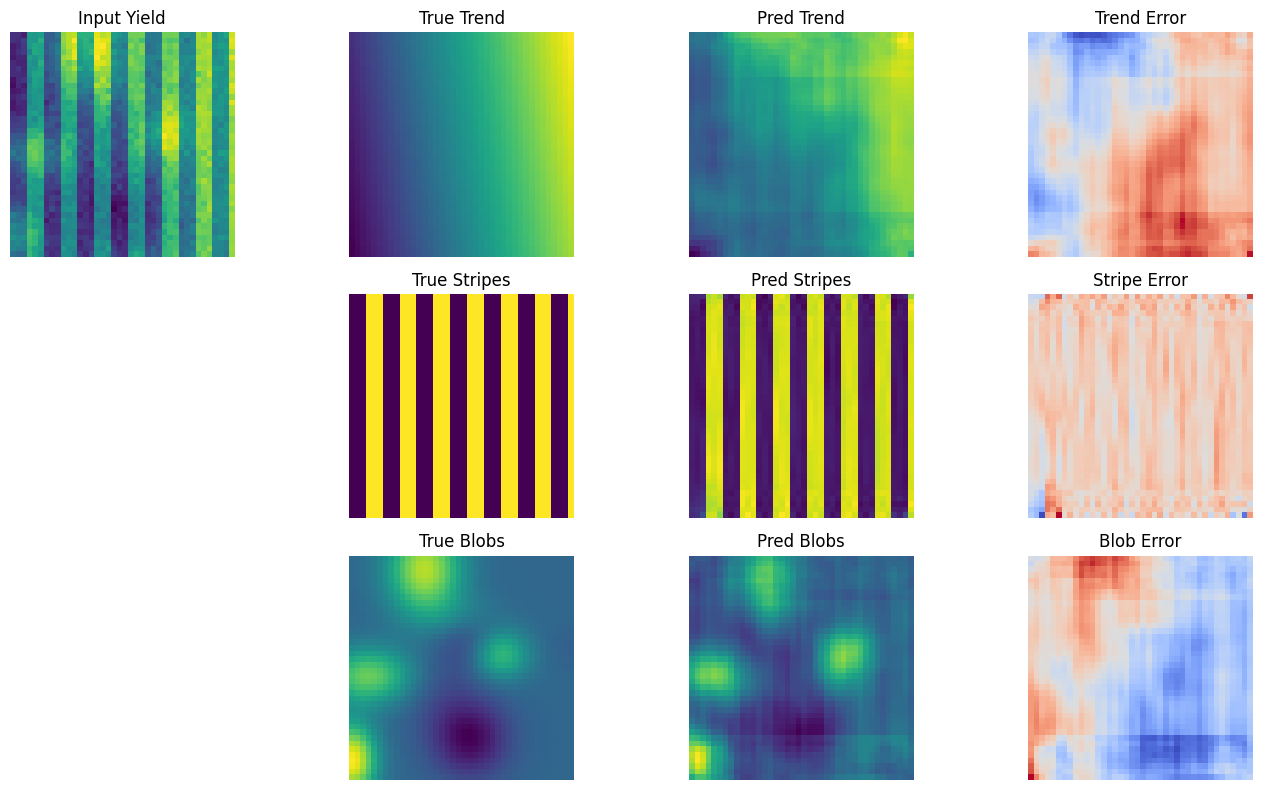

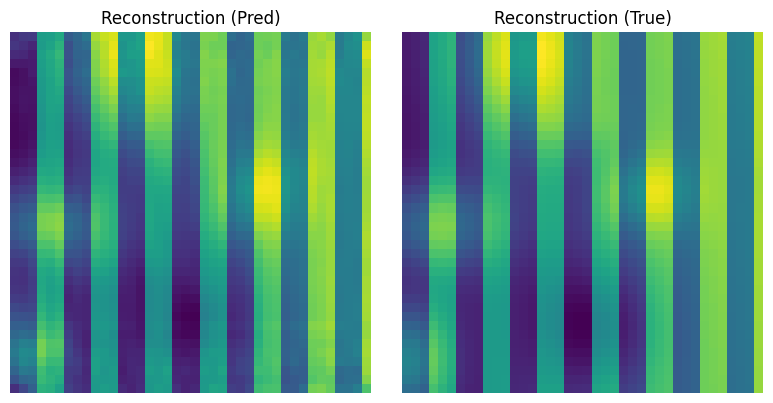

Done.


In [28]:
print("Calling evaluation...")
evaluate_model(model, device=device)
print("Done.")
